In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))

from model.network.QAN3D import Torus3DQAN
from model.network.torch_backend import TorchBackend
from model.network.visualize3D import (
    visualize_trajectory_projections, plot_trajectory_vs_decoded,
    plot_bump_tracking, plot_bump_snapshots,
)
from model.metrics import wrapped_angle_diff
from config import RunConfig, NetworkConfig


# Setup

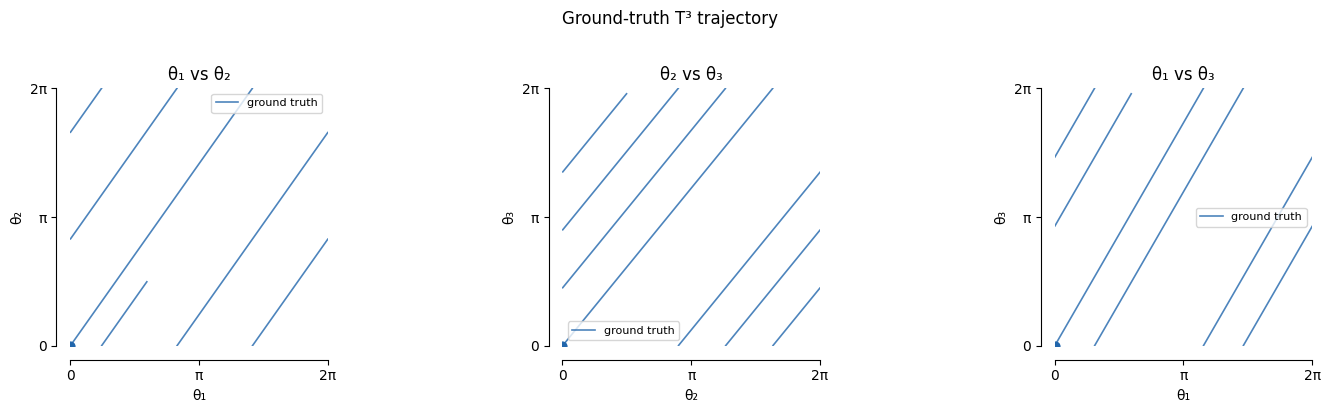

dt/tau = 0.0200 | Euler ceiling = 0.0386 | velocity drive / b = 0.013 (want << 1)


In [ ]:
cfg = RunConfig()
qan_sim = Torus3DQAN.from_config(NetworkConfig(
    spacing=0.3,            # neuron density on manifold
    dim=3,
    lambda_net=2.5,         # kernel wavelength
    ratio=1.05,             # sigma_e / sigma_i ratio (DoG width balance)
    alpha=1.0,              # Kernel_BF raw DoG gain (not a Turing margin)
    b=0.3,                  # baseline drive (keeps all neurons weakly active)
    offset_magnitude=0.19,  # δ for push-pull offset kernels
    dt=0.1,                 # forward-Euler step (NOT the drive offset)
    build_connectivity=False # FFT path or dense matrox
))

# Generate the ground-truth trajectory on T^3.
# speed is rad per unit TIME; 0.001/dt preserves the old 0.001 rad/step path.
trajectory = qan_sim.make_trajectory(n_steps=5000, speed=0.001 / qan_sim.dt)

theta_dot_max = np.abs(np.stack([
    qan_sim.theta_dot_at(trajectory, t) for t in range(1, len(trajectory))
])).max()
print(f"v/b = {qan_sim.drive_per_theta_dot * theta_dot_max / qan_sim.b:.3f}  (must stay < 1)")

fig, _ = visualize_trajectory_projections(
    trajectory,
    title="Ground-truth T³ trajectory"
)
plt.show()



# Simulate and decode 

In [ ]:
backend = TorchBackend(qan_sim)

decoded = backend.simulate(
    trajectory, settle=2000, snapshot_stride=max(1, len(trajectory) // 8))

period = backend.bump_period_cells()
m = max(1, int(round(backend.n / period)))
tr = backend.tracker
print(f"lattice spacing {period:.2f} cells → m≈{m} | "
      f"tracker radius={tr.radius} seed_radius={tr.seed_radius}")

fig, _ = plot_trajectory_vs_decoded(trajectory, decoded)
plt.show()

# Overlay decoded trajectory on ground truth 
fig, _ = visualize_trajectory_projections(
    trajectory, decoded=decoded,
    title="QAN alone: ground truth vs decoded"
)
plt.show()

fig, _ = plot_bump_snapshots(
    backend.snapshots, backend.snapshot_times, show_tracker=False)
plt.show()

KeyboardInterrupt: 

Check if the decode is good 

In [ ]:
fig, _ = plot_bump_tracking(
    backend.display_marginals,
    decoded[::backend.display_stride], backend.n,
    input_stride=backend.display_stride,
    title="Bump tracking check")
plt.show()


Normalized error (peak-tracking):   0.3246
direction cos (peak-tracking):      0.000
